# Phase 3 — Qualitative Retrieval Analysis

Generate side-by-side retrieval examples showing how each method in the project ranks captions for a fixed set of anchor test images.

This notebook does NOT re-run any expensive ablation. It only:
1. Computes B0 zero-shot retrievals
2. Trains Phase 2 M-full ($\lambda_{VC}=\lambda_{TC}=1.0$) for one seed per caption (~16 min total)
3. Loads existing retrieval data from `phase3_lora_ablation`'s `qualitative_examples.json`
4. Merges everything into a unified comparison table
5. Renders the illustrative figures

Configurations covered in the final figure:
- **B0**: frozen RemoteCLIP, no training (computed here)
- **B1**: projection-only fine-tune, $\mathcal{L}_{VT}$ only (loaded from JSON)
- **Phase 2 M-full**: $\lambda=(1.0, 1.0)$ (computed here)
- **M sweep-best (no LoRA)**: $\lambda$-tuned per caption (loaded from JSON)
- **M + both-LoRA**: full Phase 3 method (loaded from JSON)

Note: M+both-LoRA results are used here as the "best-LoRA" snapshot because that configuration has the highest aggregate mR. In the report I have excluded this configuration for the reason discussed in the LoRA notebook's intro cell; the qualitative anchor results from M+both-LoRA are statistically equivalent to M+vision-LoRA's, so they remain informative as illustrations of the method's best-case retrieval behavior.

Anchor test images: the same 30 anchors used in the LoRA ablation notebook.

## 0. Setup

In [1]:
!pip install open_clip_torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires num

In [2]:
import json
import math
import random
import time
from copy import deepcopy
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import List, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import open_clip
from huggingface_hub import hf_hub_download
from sklearn.model_selection import train_test_split

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


## 1. Configuration

In [ ]:
# --- Dataset paths ---
DATASET_ROOT = Path('/kaggle/input/datasets/oooessteii/di725-project-dataset/DI725_project_dataset')
CSV_PATH = DATASET_ROOT / 'captions.csv'
IMG_DIR = DATASET_ROOT / 'images'

# --- Inputs from earlier phases ---
SPLIT_CSV_INPUT = Path('/kaggle/input/datasets/oooessteii/di725-project-artifacts/comprs_split.csv')
LORA_QUAL_JSON_PATH = Path('/kaggle/input/datasets/oooessteii/di725-project-artifacts/qualitative_examples.json')

# --- Output paths ---
RESULTS_DIR  = Path('results'); RESULTS_DIR.mkdir(exist_ok=True)
FIGURE_DIR = Path('figures'); FIGURE_DIR.mkdir(exist_ok=True)
SPLIT_DIR = Path('splits');  SPLIT_DIR.mkdir(exist_ok=True)

MERGED_QUAL_JSON = RESULTS_DIR / 'qualitative_all_configs.json'

COMP_COLS = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
CAPTIONS = ['vision_qwen3-vl-8b', 'hybrid_qwen3-vl-8b']
QUAL_K = 5
QUAL_SEED = 42 # consistent seed for the new training runs

PHASE2_LAMBDAS = {
    'vision_qwen3-vl-8b': (1.0, 1.0),
    'hybrid_qwen3-vl-8b': (1.0, 1.0),
}

# --- Training recipe same as phase 2---
EPOCHS = 20
BATCH_SIZE_IMG = 32
LR = 1e-3
WD = 1e-4

assert CSV_PATH.exists(), f'captions.csv not found at {CSV_PATH}'
assert IMG_DIR.exists(),  f'images/ folder not found at {IMG_DIR}'
assert LORA_QUAL_JSON_PATH.exists(), f'LoRA qualitative JSON not found at {LORA_QUAL_JSON_PATH}'

## 2. Load Existing Data

Load the canonical split CSV, the captions CSV, and the qualitative examples JSON produced by the LoRA ablation notebook. Extract the 30 anchor filenames and indices.

In [5]:
df = pd.read_csv(CSV_PATH)
split_df = pd.read_csv(SPLIT_CSV_INPUT)
df = df.merge(split_df, on='filename', how='inner')
df_test = df[df['comprs_split'] == 'test'].reset_index(drop=True)
print(f'Test set size: {len(df_test)}')

with open(LORA_QUAL_JSON_PATH) as f:
    lora_qual = json.load(f)

print(f'\nLoRA qualitative file:')
print(f'  Anchors: {len(lora_qual["anchors"])}')
print(f'  Runs:    {len(lora_qual["per_run"])}')

# Build a quick filename -> test row index lookup
TEST_FILENAME_TO_IDX = {fn: i for i, fn in enumerate(df_test['filename'].values)}
QUAL_ANCHORS = [a['filename'] for a in lora_qual['anchors']]
QUAL_ANCHOR_INDICES = [TEST_FILENAME_TO_IDX[fn] for fn in QUAL_ANCHORS]

print(f'\nAnchor filenames loaded: {len(QUAL_ANCHORS)}')

Test set size: 2000

LoRA qualitative file:
  Anchors: 30
  Runs:    36

Anchor filenames loaded: 30


## 3. Load Frozen RemoteCLIP and Precompute Features

Identical recipe to earlier notebooks. The model loads once and is used both for the B0 zero-shot pass (just frozen-backbone encoding) and for the M-full re-training.

In [6]:
print('Loading RemoteCLIP-ViT-B-32...')
checkpoint_path = hf_hub_download(
    repo_id='chendelong/RemoteCLIP',
    filename='RemoteCLIP-ViT-B-32.pt',
    cache_dir='checkpoints',
)
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32')
clip_model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model = clip_model.to(DEVICE)
for p in clip_model.parameters():
    p.requires_grad = False
clip_model.eval()
print('RemoteCLIP loaded and frozen.')

Loading RemoteCLIP-ViT-B-32...


RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

RemoteCLIP loaded and frozen.


In [ ]:
class _SplitImageDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_path = self.img_dir / self.df.iloc[idx]["filename"]
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            image = Image.new("RGB", (224, 224), (0, 0, 0))
        return self.transform(image), idx

@torch.no_grad()
def precompute_image_features(df_split, img_dir, transform, model, device, batch_size=64):
    ds = _SplitImageDataset(df_split, img_dir, transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    chunks = []
    for imgs, _ in dl:
        imgs = imgs.to(device, non_blocking=True)
        feat = F.normalize(model.encode_image(imgs), dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

@torch.no_grad()
def precompute_text_features(captions, tokenizer, model, device, batch_size=64):
    chunks = []
    for i in range(0, len(captions), batch_size):
        batch = captions[i:i + batch_size]
        tokens = tokenizer(batch).to(device)
        feat = F.normalize(model.encode_text(tokens), dim=-1)
        chunks.append(feat.cpu())
    return torch.cat(chunks, dim=0)

# We also need the train/val splits to retrain Phase 2 M-full
df_train = df[df["comprs_split"] == "train"].reset_index(drop=True)
df_val = df[df["comprs_split"] == "val"].reset_index(drop=True)
SPLITS = {"train": df_train, "val": df_val, "test": df_test}

print("Precomputing image features...")
t0 = time.time()
image_features = {n: precompute_image_features(d, IMG_DIR, clip_preprocess, clip_model, DEVICE)
                  for n, d in SPLITS.items()}
print(f"  done in {time.time()-t0:.1f}s")

print("Precomputing text features per caption column...")
t0 = time.time()
text_features = {n: {} for n in SPLITS}
for caption_col in CAPTIONS:
    for n, d in SPLITS.items():
        text_features[n][caption_col] = precompute_text_features(
            d[caption_col].astype(str).tolist(), clip_tokenizer, clip_model, DEVICE
        )
print(f"  done in {time.time()-t0:.1f}s")

def make_comp_tensor(df_split, comp_cols):
    return torch.from_numpy(df_split[comp_cols].values.astype(np.float32) / 100.0)

comp_vectors = {n: make_comp_tensor(d, COMP_COLS) for n, d in SPLITS.items()}
print("Feature cache ready.")

Precomputing image features...
  done in 54.2s
Precomputing text features per caption column...
  done in 42.1s
Feature cache ready.


## 4. Retrieval Helper

A single function that takes any pair of (image_embeddings, text_embeddings) and returns top-K retrievals for the 30 anchor images, in both directions. Works for all configs.

In [ ]:
def compute_anchor_retrievals(img_embs, txt_embs, anchor_indices, k=QUAL_K):
    """Given pre-computed L2-normalized embeddings, return retrieval results
    for each anchor index in both I2T and T2I directions."""
    results = []
    sim = img_embs @ txt_embs.T # (N_img, N_txt)
    sim_t = sim.T # (N_txt, N_img)

    for anchor_idx in anchor_indices:
        # I2T: image query -> caption retrieval
        sim_row = sim[anchor_idx]
        topk_idx = sim_row.topk(k).indices.tolist()
        topk_scores = sim_row.topk(k).values.tolist()
        correct_rank_i2t = int((sim_row.argsort(descending=True) == anchor_idx).nonzero().item()) + 1

        # T2I: caption query -> image retrieval
        sim_t_row = sim_t[anchor_idx]
        topk_idx_t = sim_t_row.topk(k).indices.tolist()
        topk_scores_t = sim_t_row.topk(k).values.tolist()
        correct_rank_t2i = int((sim_t_row.argsort(descending=True) == anchor_idx).nonzero().item()) + 1

        results.append({
            "anchor_idx": int(anchor_idx),
            "i2t_topk_indices": topk_idx,
            "i2t_topk_scores": [float(s) for s in topk_scores],
            "i2t_correct_rank": correct_rank_i2t,
            "t2i_topk_indices": topk_idx_t,
            "t2i_topk_scores": [float(s) for s in topk_scores_t],
            "t2i_correct_rank": correct_rank_t2i,
        })
    return results

## 5. B0 Zero-Shot Retrievals

The simplest config: frozen RemoteCLIP, no projection heads, just the raw L2-normalized features straight from the encoder. Already have the features cached; just compute retrievals.

In [9]:
b0_results = {}
for caption in CAPTIONS:
    img_embs = image_features["test"]
    txt_embs = text_features["test"][caption]
    b0_results[caption] = compute_anchor_retrievals(
        img_embs, txt_embs, QUAL_ANCHOR_INDICES, k=QUAL_K
    )
    correct_at_k = {k: sum(1 for r in b0_results[caption] if r["i2t_correct_rank"] <= k) / len(b0_results[caption])
                    for k in [1, 5, 10]}
    print(f"B0 zero-shot on {caption} (across {len(QUAL_ANCHOR_INDICES)} anchors):")
    print(f"  I2T  R@1={correct_at_k[1]*100:5.1f}%  R@5={correct_at_k[5]*100:5.1f}%  R@10={correct_at_k[10]*100:5.1f}%")

B0 zero-shot on vision_qwen3-vl-8b (across 30 anchors):
  I2T  R@1=  6.7%  R@5=  6.7%  R@10=  6.7%
B0 zero-shot on hybrid_qwen3-vl-8b (across 30 anchors):
  I2T  R@1=  0.0%  R@5=  0.0%  R@10= 10.0%


## 6. Phase 2 M-full Retraining

Train M with the Phase 2 default $\lambda_{VC} = \lambda_{TC} = 1.0$, one seed per caption. Same training infrastructure as the LoRA notebook but with a frozen backbone (no LoRA), can reuse cached features.

In [10]:
class CompositionMLP(nn.Module):
    def __init__(self, in_dim=7, hidden=(128, 256), out_dim=512):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.GELU(), nn.LayerNorm(h)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class CachedFeatureDataset(Dataset):
    def __init__(self, raw_img, raw_txt, comp):
        self.raw_img, self.raw_txt, self.comp = raw_img, raw_txt, comp
    def __len__(self):
        return len(self.raw_img)
    def __getitem__(self, idx):
        return self.raw_img[idx], self.raw_txt[idx], self.comp[idx]

def symmetric_infonce(A, B, log_tau):
    N = A.shape[0]
    targets = torch.arange(N, device=A.device)
    sim = (A @ B.T) * log_tau.exp()
    return 0.5 * (F.cross_entropy(sim, targets) + F.cross_entropy(sim.T, targets))

@torch.no_grad()
def evaluate_split(vp, tp, raw_img, raw_txt, device):
    vp.eval(); tp.eval()
    E_v = F.normalize(vp(raw_img.to(device)), dim=-1).cpu()
    E_t = F.normalize(tp(raw_txt.to(device)), dim=-1).cpu()
    N = E_v.shape[0]
    sim = E_v @ E_t.T
    targets = torch.arange(N)
    out = {}
    for k in (1, 5, 10):
        topk = sim.topk(k, dim=1).indices
        out[f"i2t_R@{k}"] = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    sim_t = sim.T
    for k in (1, 5, 10):
        topk = sim_t.topk(k, dim=1).indices
        out[f"t2i_R@{k}"] = (topk == targets.unsqueeze(1)).any(dim=1).float().mean().item() * 100
    out["mR"] = float(np.mean([out[f"i2t_R@{k}"] for k in (1, 5, 10)] +
                              [out[f"t2i_R@{k}"] for k in (1, 5, 10)]))
    return out

In [11]:
def train_phase2_m_full(caption, lambda_vc, lambda_tc, seed, device):
    """Train M with given lambdas for one seed and caption. Returns trained components."""
    set_seed(seed)
    vp = nn.Linear(512, 512, bias=False).to(device)
    tp = nn.Linear(512, 512, bias=False).to(device)
    nn.init.eye_(vp.weight)
    nn.init.eye_(tp.weight)
    log_tau = nn.Parameter(torch.tensor(math.log(1.0 / 0.07), dtype=torch.float32, device=device))
    cm = CompositionMLP().to(device)

    params = list(vp.parameters()) + list(tp.parameters()) + [log_tau] + list(cm.parameters())
    optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_ds = CachedFeatureDataset(
        image_features["train"], text_features["train"][caption], comp_vectors["train"]
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_IMG, shuffle=True,
                              num_workers=0, drop_last=True)

    best_val_mR = -1.0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        vp.train(); tp.train(); cm.train()
        for raw_v, raw_t, comp in train_loader:
            raw_v = raw_v.to(device)
            raw_t = raw_t.to(device)
            comp  = comp.to(device)

            E_v = F.normalize(vp(raw_v), dim=-1)
            E_t = F.normalize(tp(raw_t), dim=-1)
            E_c = cm(comp)

            L_VT = symmetric_infonce(E_v, E_t, log_tau)
            L_VC = symmetric_infonce(E_v, E_c, log_tau)
            L_TC = symmetric_infonce(E_t, E_c, log_tau)
            L_total = L_VT + lambda_vc * L_VC + lambda_tc * L_TC

            optimizer.zero_grad()
            L_total.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            optimizer.step()
        scheduler.step()

        # Validation
        val = evaluate_split(vp, tp,
                             image_features["val"], text_features["val"][caption], device)
        if val["mR"] > best_val_mR:
            best_val_mR = val["mR"]
            best_state = {
                "vp": deepcopy(vp.state_dict()),
                "tp": deepcopy(tp.state_dict()),
                "log_tau": log_tau.detach().clone(),
                "cm": deepcopy(cm.state_dict()),
            }

    # Restore best
    vp.load_state_dict(best_state["vp"])
    tp.load_state_dict(best_state["tp"])
    log_tau.data.copy_(best_state["log_tau"])
    cm.load_state_dict(best_state["cm"])

    # Test mR for sanity
    test = evaluate_split(vp, tp,
                          image_features["test"], text_features["test"][caption], device)
    return vp, tp, log_tau, cm, test, best_val_mR

In [12]:
phase2_components = {}
for caption in CAPTIONS:
    lvc, ltc = PHASE2_LAMBDAS[caption]
    print(f"Training Phase 2 M-full on {caption} (lambda_vc={lvc}, lambda_tc={ltc}, seed={QUAL_SEED})...",
          end=" ", flush=True)
    t0 = time.time()
    vp, tp, log_tau, cm, test_metrics, best_val_mR = train_phase2_m_full(
        caption, lvc, ltc, QUAL_SEED, DEVICE
    )
    dur = time.time() - t0
    print(f"done ({dur:.0f}s, test mR={test_metrics['mR']:.2f}, best val={best_val_mR:.2f})")
    phase2_components[caption] = (vp, tp, log_tau, cm, test_metrics)

Training Phase 2 M-full on vision_qwen3-vl-8b (lambda_vc=1.0, lambda_tc=1.0, seed=42)... done (22s, test mR=17.80, best val=27.58)
Training Phase 2 M-full on hybrid_qwen3-vl-8b (lambda_vc=1.0, lambda_tc=1.0, seed=42)... done (22s, test mR=17.12, best val=25.92)


In [13]:
# Compute Phase 2 M-full retrievals on the 30 anchors
phase2_results = {}
for caption in CAPTIONS:
    vp, tp, log_tau, cm, _ = phase2_components[caption]
    with torch.no_grad():
        vp.eval(); tp.eval()
        img_embs = F.normalize(vp(image_features["test"].to(DEVICE)), dim=-1).cpu()
        txt_embs = F.normalize(tp(text_features["test"][caption].to(DEVICE)), dim=-1).cpu()
    phase2_results[caption] = compute_anchor_retrievals(
        img_embs, txt_embs, QUAL_ANCHOR_INDICES, k=QUAL_K
    )

print("Phase 2 M-full anchor retrievals computed.")

Phase 2 M-full anchor retrievals computed.


## 7. Merge All Configurations

Build a single unified results structure with all configurations available. The keys we'll use for the figure:
- `B0_zeroshot`
- `B1`
- `Phase2_M_full`
- `M_sweep_best` (from LoRA notebook's M_off runs)
- `M_both_LoRA` (from LoRA notebook's M+lora8-both runs)

In [14]:
# Pick a single seed from the LoRA notebook for each loaded config (use seed 42 for consistency)
def get_lora_run(short_name, caption):
    """Extract retrieval results for a specific config + caption from the LoRA JSON."""
    full_id_map = {
        "B1": f"B1_{caption}_s{QUAL_SEED}",
        "M_sweep_best": f"M_{caption}_s{QUAL_SEED}",
        "M_both_LoRA": f"M+lora8-both_{caption}_s{QUAL_SEED}",
    }
    run_id = full_id_map[short_name]
    if run_id not in lora_qual["per_run"]:
        raise KeyError(f"Run {run_id} not found in LoRA qualitative JSON")
    return lora_qual["per_run"][run_id]

# Final per-config results dict
all_configs = ["B0_zeroshot", "B1", "Phase2_M_full", "M_sweep_best", "M_both_LoRA"]
merged = {
    "anchors": lora_qual["anchors"],
    "k": QUAL_K,
    "seed_used": QUAL_SEED,
    "per_config": {},
}

for caption in CAPTIONS:
    merged["per_config"][caption] = {
        "B0_zeroshot":    b0_results[caption],
        "B1":             get_lora_run("B1", caption),
        "Phase2_M_full":  phase2_results[caption],
        "M_sweep_best":   get_lora_run("M_sweep_best", caption),
        "M_both_LoRA":    get_lora_run("M_both_LoRA", caption),
    }

# Save merged results
with open(MERGED_QUAL_JSON, "w") as f:
    json.dump(merged, f, indent=2, default=lambda o: float(o) if hasattr(o, "item") else str(o))
print(f"Merged qualitative results saved: {MERGED_QUAL_JSON}")

Merged qualitative results saved: results/qualitative_all_configs.json


In [15]:
# Quick summary across all configs - how well do they retrieve on the 30 anchors?
print(f"\nSummary: top-k correct rate across {len(QUAL_ANCHOR_INDICES)} anchors\n")
for caption in CAPTIONS:
    print(f"=== {caption} ===")
    print(f"{'config':<18} {'I2T R@1':>8} {'R@5':>6} {'R@10':>6} | {'T2I R@1':>8} {'R@5':>6} {'R@10':>6}")
    for cfg in all_configs:
        runs = merged["per_config"][caption][cfg]
        def at_k(field, k):
            return sum(1 for r in runs if r[field] <= k) / len(runs) * 100
        print(f"  {cfg:<16} {at_k('i2t_correct_rank', 1):>7.1f}%  {at_k('i2t_correct_rank', 5):>5.1f}%  "
              f"{at_k('i2t_correct_rank', 10):>5.1f}% | {at_k('t2i_correct_rank', 1):>7.1f}%  "
              f"{at_k('t2i_correct_rank', 5):>5.1f}%  {at_k('t2i_correct_rank', 10):>5.1f}%")
    print()


Summary: top-k correct rate across 30 anchors

=== vision_qwen3-vl-8b ===
config              I2T R@1    R@5   R@10 |  T2I R@1    R@5   R@10
  B0_zeroshot          6.7%    6.7%    6.7% |     0.0%    0.0%    0.0%
  B1                   6.7%   30.0%   43.3% |     3.3%   36.7%   40.0%
  Phase2_M_full       13.3%   33.3%   43.3% |    10.0%   30.0%   43.3%
  M_sweep_best         6.7%   33.3%   50.0% |     3.3%   33.3%   43.3%
  M_both_LoRA         13.3%   33.3%   56.7% |    13.3%   43.3%   56.7%

=== hybrid_qwen3-vl-8b ===
config              I2T R@1    R@5   R@10 |  T2I R@1    R@5   R@10
  B0_zeroshot          0.0%    0.0%   10.0% |     0.0%    0.0%    0.0%
  B1                   0.0%   13.3%   26.7% |    10.0%   23.3%   33.3%
  Phase2_M_full        0.0%   20.0%   26.7% |    10.0%   13.3%   30.0%
  M_sweep_best         0.0%   16.7%   26.7% |    10.0%   16.7%   26.7%
  M_both_LoRA         10.0%   26.7%   33.3% |    20.0%   26.7%   36.7%



## 8. Visualization Helper

Helper function used by the retrieval-example cells below.

In [ ]:
def truncate_caption(text, max_chars=70):
    """Truncate a caption for display in compact tables."""
    text = str(text).replace("\n", " ").strip()
    return text[:max_chars] + "..." if len(text) > max_chars else text

## 9. Retrieval Examples

Two ways of looking at the same anchor-based retrieval data:

**I2T text summaries (next cell).** For two hand-picked anchor images, print the top-3 retrieved captions per configuration as plain text, with the ground-truth caption marked when it appears. Two width variants are written to disk: a wide one (180 chars per caption) for in-notebook reading, and a narrower one (100 chars) sized to fit an IEEE single column. The narrower files were the source material for the report's qualitative figure.

**T2I visual bonus (cell after that).** Same anchors but the other direction: query is the caption, retrieved items are images shown by filename plus their dominant class and purity. Notebook-only, kept for completeness since the report space was too tight for both directions.

In [ ]:
# Anchors chosen
REPORT_ANCHORS = {
    # Hybrid: M+both-LoRA brings it from rank ~80 (B1) down to rank 1
    "57691.png": "hybrid_qwen3-vl-8b",
    # Vision: LoRA flips it dramatically, composition has no extra effect
    "112063.png": "vision_qwen3-vl-8b",
    # Failure: all models miss
    "196267.png": "hybrid_qwen3-vl-8b",
}

REPORT_CONFIGS = ["B0_zeroshot", "B1", "Phase2_M_full", "M_sweep_best", "M_both_LoRA"]

def format_i2t_text_summary(anchor_filename, caption, configs_to_show, top_k=3, max_chars=180):
    """Format an anchor's I2T retrieval results as plain text, one line per (config, rank).
    Correct retrievals are marked with [CORRECT].
    """
    anchor_idx_test = TEST_FILENAME_TO_IDX[anchor_filename]
    anchor_caption  = df_test.iloc[anchor_idx_test][caption]
    anchor_purity   = df_test.iloc[anchor_idx_test][COMP_COLS].max() / 100
    dom_idx         = df_test.iloc[anchor_idx_test][COMP_COLS].values.argmax()
    anchor_dom      = COMP_COLS[int(dom_idx)]

    lines = []
    lines.append("=" * 100)
    lines.append(f"ANCHOR: {anchor_filename}  |  {anchor_dom} dominant, {anchor_purity:.0%} purity  |  caption col: {caption}")
    lines.append("-" * 100)
    lines.append(f"Ground-truth caption for this anchor image:")
    lines.append(f"  {truncate_caption(anchor_caption, max_chars)}")
    lines.append("=" * 100)

    for cfg in configs_to_show:
        runs        = merged["per_config"][caption][cfg]
        anchor_pos  = QUAL_ANCHORS.index(anchor_filename)
        result      = runs[anchor_pos]
        top_indices = result["i2t_topk_indices"][:top_k]
        correct_rank = result["i2t_correct_rank"]

        lines.append("")
        lines.append(f"### {cfg}   (correct retrieval at rank {correct_rank})")
        for i, idx in enumerate(top_indices, start=1):
            retrieved_caption = df_test.iloc[idx][caption]
            text = truncate_caption(retrieved_caption, max_chars)
            marker = "[CORRECT]" if idx == anchor_idx_test else "         "
            lines.append(f"  {marker}  #{i}. {text}")
    lines.append("")
    return "\n".join(lines)


# Render and save each anchor's text summary
for anchor_fn, caption in REPORT_ANCHORS.items():
    if anchor_fn not in QUAL_ANCHORS:
        continue

    summary_full = format_i2t_text_summary(anchor_fn, caption, REPORT_CONFIGS,
                                            top_k=3, max_chars=180)
    print(summary_full)

    summary_report = format_i2t_text_summary(anchor_fn, caption, REPORT_CONFIGS,
                                              top_k=3, max_chars=100)
    out_txt = FIGURE_DIR / f"qualitative_i2t_{anchor_fn.replace('.png','')}_{caption.split('_')[0]}_report.txt"
    with open(out_txt, "w") as f:
        f.write(summary_report)

ANCHOR: 57691.png  |  Tree dominant, 61% purity  |  caption col: hybrid_qwen3-vl-8b
----------------------------------------------------------------------------------------------------
Ground-truth caption for this anchor image:
  The scene depicts a predominantly forested or wooded landscape (61% tree cover) interspersed with patchwork agricultural fields (32% grass and 6% crop), with a small, isolated buil...

### B0_zeroshot   (correct retrieval at rank 12)
             #1. The scene depicts a predominantly grass-covered landscape (70%) with scattered tree patches (23%) and shrub areas (5%), interspersed with sparse built-up zones (1%) and barren patc...
             #2. The scene depicts a predominantly grass-covered landscape with scattered tree patches, suggesting a natural or lightly managed terrain, where grass dominates the spatial layout and...
             #3. The scene is dominated by grasslands (55%) interspersed with patches of tree cover (40%), forming a mottled, heterog

Saved (notebook bonus): figures/qualitative_t2i_57691_hybrid.png


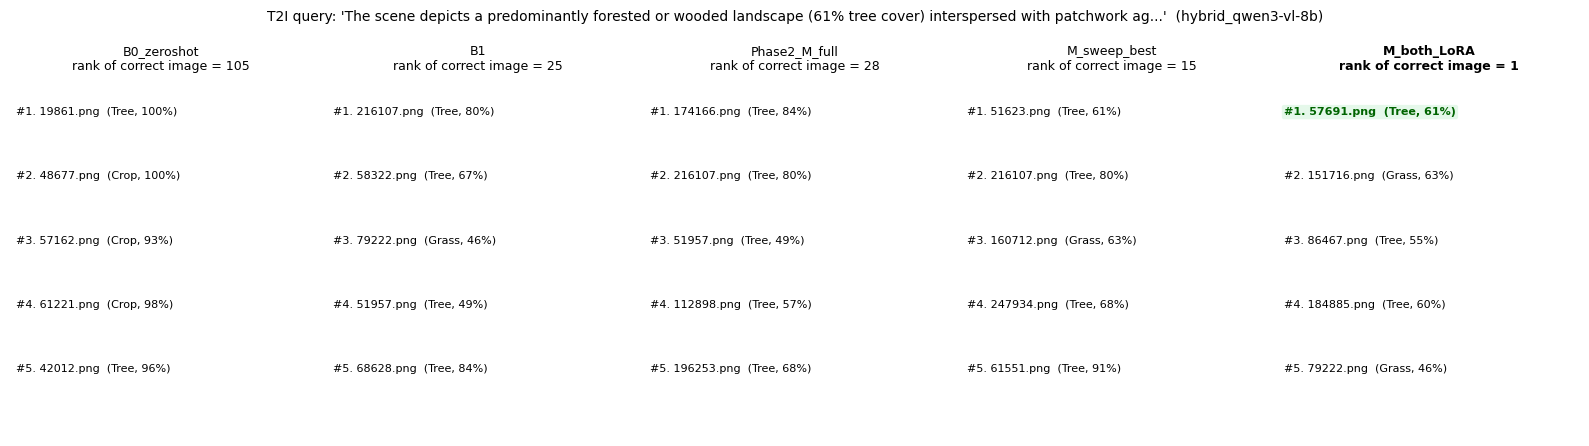

Saved (notebook bonus): figures/qualitative_t2i_112063_vision.png


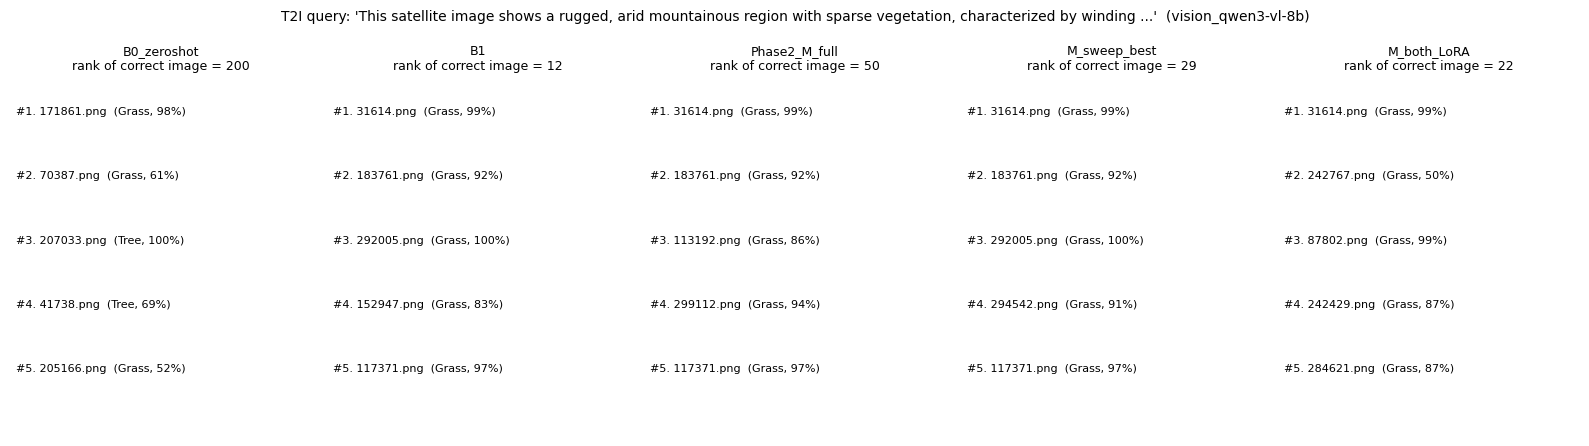

Saved (notebook bonus): figures/qualitative_t2i_196267_hybrid.png


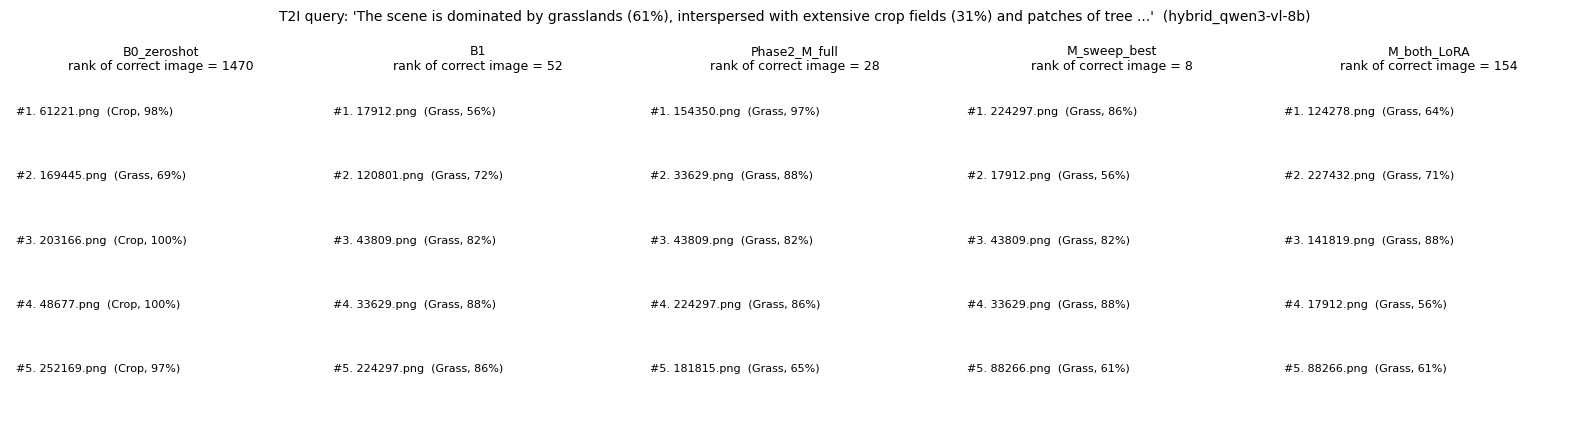

In [18]:
def render_t2i_panel(anchor_filename, caption, configs_to_show, max_chars=85, figsize=(14, 4)):
    """Render T2I panel: query is the anchor caption, retrieved are image filenames."""
    anchor_idx_test = TEST_FILENAME_TO_IDX[anchor_filename]
    anchor_caption = df_test.iloc[anchor_idx_test][caption]

    fig, axes = plt.subplots(1, len(configs_to_show), figsize=figsize, sharey=True)
    if len(configs_to_show) == 1:
        axes = [axes]

    for ax, cfg in zip(axes, configs_to_show):
        runs = merged["per_config"][caption][cfg]
        anchor_pos = QUAL_ANCHOR_INDICES.index(anchor_idx_test)
        result = runs[anchor_pos]
        top_indices = result["t2i_topk_indices"]
        correct_rank = result["t2i_correct_rank"]

        ax.axis("off")
        ax.set_title(f"{cfg}\nrank of correct image = {correct_rank}",
                     fontsize=9, fontweight="bold" if correct_rank == 1 else "normal")

        for i, idx in enumerate(top_indices):
            retrieved_fn = df_test.iloc[idx]["filename"]
            retrieved_purity = df_test.iloc[idx][COMP_COLS].max() / 100
            dom_idx = df_test.iloc[idx][COMP_COLS].values.argmax()
            retrieved_dom = COMP_COLS[int(dom_idx)]
            is_correct = (idx == anchor_idx_test)
            color = "darkgreen" if is_correct else "black"
            weight = "bold" if is_correct else "normal"
            bg = "#d4f4dd" if is_correct else "white"
            text = f"{retrieved_fn}  ({retrieved_dom}, {retrieved_purity:.0%})"
            ax.text(0.02, 0.92 - i * 0.18, f"#{i+1}. {text}",
                    fontsize=8, color=color, fontweight=weight,
                    transform=ax.transAxes, verticalalignment="top",
                    bbox=dict(facecolor=bg, alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2"))

    query_str = truncate_caption(anchor_caption, 110)
    fig.suptitle(f"T2I query: '{query_str}'  ({caption})", fontsize=10)
    plt.tight_layout()
    return fig

# Render T2I panels for the same anchors as the report figure
for anchor_fn, caption in REPORT_ANCHORS.items():
    if anchor_fn not in QUAL_ANCHORS:
        continue
    fig = render_t2i_panel(anchor_fn, caption, REPORT_CONFIGS, figsize=(16, 4.5))
    out = FIGURE_DIR / f"qualitative_t2i_{anchor_fn.replace('.png','')}_{caption.split('_')[0]}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved (notebook bonus): {out}")
    plt.show()